In [1]:
import random
from pathlib import Path

import numpy as np
from myterial import orange
from rich import print
import pandas as pd

from brainrender import Scene, settings
from brainrender.actors import Points, Cylinder, Point
from brainglobe_atlasapi import BrainGlobeAtlas
import matplotlib.pyplot as plt

from skimage import measure

settings.SHOW_AXES = False
settings.WHOLE_SCREEN = False
import sys
import os
import pathlib
try:
    _here = pathlib.Path(__file__).resolve().parent          # script mode
except NameError:
    try:
        _here = pathlib.Path(__vsc_ipynb_file__).resolve().parent  # VS Code notebook
    except NameError:
        _here = pathlib.Path(os.getcwd())                    # other Jupyter fallback

_beh_ephys_root = str((_here / '../..').resolve())
if _beh_ephys_root not in sys.path:
    sys.path.insert(0, _beh_ephys_root)

from utils.capsule_migration import capsule_directories


In [2]:
capsule_dirs = capsule_directories()

atlas = BrainGlobeAtlas("allen_mouse_25um")

template = atlas.reference   # grayscale brain
annotation = atlas.annotation

In [3]:
ccf_file = '/data/FP_location/PL_ccf_coordinates_pir.csv'
ccf_locations = pd.read_csv(ccf_file)
PL_coordinates = ccf_locations[['x', 'y', 'z']].values * 25  # convert to microns

bregma = np.array([216, 18, 228]).reshape(1, 3) * 25  # in microns

origin = np.array([0, 0, 0]).reshape(1, 3)

PL_coordinates_flip = PL_coordinates.copy()
PL_coordinates_flip[:, 2] = 2*bregma[:, 2] - PL_coordinates_flip[:, 2]  # flip z-axis

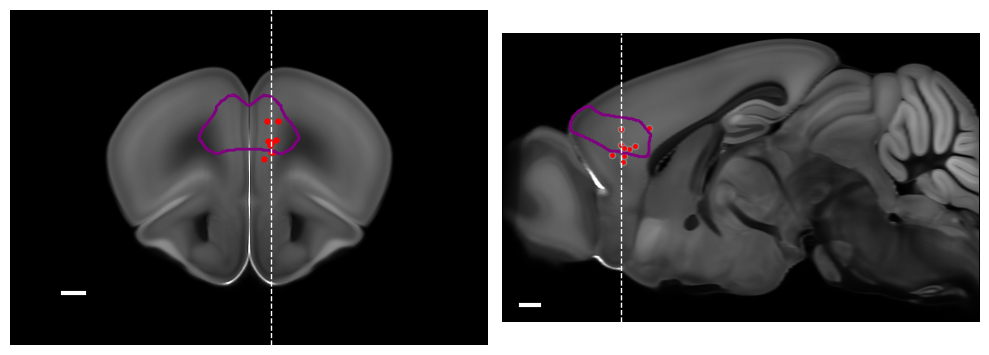

In [4]:

atlas = BrainGlobeAtlas("allen_mouse_25um")
template = atlas.reference
annotation = atlas.annotation

pl_ids = [972, 171, 195, 304, 363, 84]

voxel = 25
coords_voxel = PL_coordinates_flip / voxel
bregma_voxel = bregma / voxel

# BrainGlobe axis order: (AP, DV, ML)
ap = coords_voxel[:, 0]
dv = coords_voxel[:, 1]
ml = coords_voxel[:, 2]

ap_slice = 130
ml_slice = int(np.round(np.mean(ml)))

# full 3D PL mask
pl_mask_3d = np.isin(annotation, pl_ids)

# maximum projections of PL annotation
# coronal view lives in (DV, ML), so project over AP
mask_cor_proj = np.any(pl_mask_3d, axis=0)

# sagittal view lives in (AP, DV), so project over ML
mask_sag_proj = np.any(pl_mask_3d, axis=2)

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

# -------------------------
# Coronal view
# background = one AP section
# PL boundary = max projection over AP
# x = ML, y = DV
# -------------------------
axes[0].imshow(template[ap_slice, :, :], cmap="gray")

contours = measure.find_contours(mask_cor_proj.astype(float), 0.5)
for contour in contours:
    axes[0].plot(contour[:, 1], contour[:, 0], color="purple", linewidth=2)

axes[0].scatter(ml, dv, c="r", s=20, edgecolor=(0.5, 0.5, 0.5, 0), linewidth=1)
# axes[0].scatter(
#     bregma_voxel[0, 2], bregma_voxel[0, 1],
#     c="red", s=50, marker="x"
# )

# sagittal slice location on coronal: fixed ML
axes[0].axvline(ml_slice, color="white", linestyle="--", linewidth=1)

axes[0].axis("off")

# add scale bar
scalebar_length = 500  # in micrometers
scalebar_length_voxels = scalebar_length / voxel
axes[0].plot(
    [50, 50 + scalebar_length_voxels], [template.shape[1] - 50, template.shape[1] - 50],
    color="white", linewidth=3
)
# axes[0].set_xlim(0+20, template.shape[2]-20)
# axes[0].set_ylim(template.shape[1]-20, 0+20)

# -------------------------
# Sagittal view
# background = one ML section
# PL boundary = max projection over ML
# imshow(template[:, :, ml_slice]) => x = DV, y = AP
# -------------------------
# rotate background
# -------------------------
# Sagittal view, clean mapping
# displayed axes: x = AP, y = DV
# -------------------------

# background and PL mask
sag_img = template[:, :, ml_slice]          # (AP, DV)
sag_mask = mask_sag_proj.astype(float)      # (AP, DV)

# rotate clockwise, then flip horizontally
sag_img_show = np.fliplr(np.rot90(sag_img, k=-1))
sag_mask_show = np.fliplr(np.rot90(sag_mask, k=-1))

axes[1].imshow(sag_img_show, cmap="gray")

# PL boundary
contours = measure.find_contours(sag_mask_show, 0.5)
for contour in contours:
    axes[1].plot(contour[:, 1], contour[:, 0], color="purple", linewidth=2)

# clean coordinate mapping after rotate+fliplr:
# x = AP, y = DV
axes[1].scatter(ap, dv, c="r", s=20, edgecolor=(0.5, 0.5, 0.5, 1), linewidth=1)

# # bregma
# axes[1].scatter(
#     bregma_voxel[0, 0],
#     bregma_voxel[0, 1],
#     c="red", s=50, marker="x"
# )

# coronal slice location = fixed AP => vertical line
axes[1].axvline(ap_slice, color="white", linestyle="--", linewidth=1)

# add scale bar
scalebar_length_voxels = scalebar_length / voxel
height, width = sag_img_show.shape

axes[1].plot(
    [20, 20 + scalebar_length_voxels],
    [height - 20, height - 20],
    color="white",
    linewidth=3
)
axes[1].axis("off")

plt.tight_layout()
# plt.show()

save_dir = os.path.join(capsule_dirs['manuscript_fig_dir'], 'F_FP_locations')
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
plt.savefig(os.path.join(save_dir, "FigureS17b_PL_fiber_ccf_plot.svg"))
curr_csv = pd.DataFrame({'ap':coords_voxel[:, 0], 
                        'ml': coords_voxel[:, 2],
                        'dv': coords_voxel[:, 1]})
curr_csv.to_csv(os.path.join(save_dir, "FigureS17b_PL_fiber_ccf_plot.csv"))
    